In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("default")

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

PROCESSED_PATH = BASE_DIR / "data" / "processed"

fund_master = pd.read_csv(
    PROCESSED_PATH / "01_fund_master_clean.csv"
)

nav_history = pd.read_csv(
    PROCESSED_PATH / "02_nav_history_clean.csv"
)

scheme_performance = pd.read_csv(
    PROCESSED_PATH / "07_scheme_performance_clean.csv"
)

portfolio_holdings = pd.read_csv(
    PROCESSED_PATH / "09_portfolio_holdings_clean.csv"
)

benchmark_indices = pd.read_csv(
    PROCESSED_PATH / "10_benchmark_indices_clean.csv"
)

print("Data Loaded")

Data Loaded


In [3]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "Scheme Performance": scheme_performance,
    "Portfolio Holdings": portfolio_holdings,
    "Benchmark": benchmark_indices
}

for name, df in datasets.items():

    print("=" * 60)

    print(name)

    print("=" * 60)

    print("Shape:", df.shape)

    print()

Fund Master
Shape: (40, 15)

NAV History
Shape: (46000, 3)

Scheme Performance
Shape: (40, 19)

Portfolio Holdings
Shape: (322, 8)

Benchmark
Shape: (8050, 3)



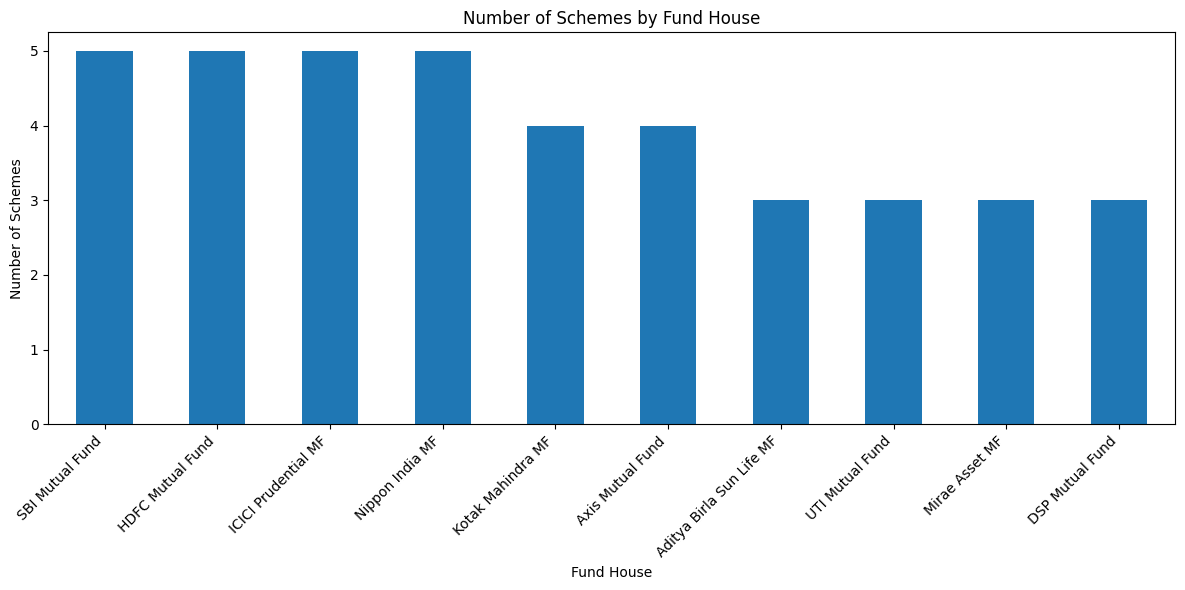

In [5]:
fund_counts = fund_master["fund_house"].value_counts()

plt.figure(figsize=(12,6))

fund_counts.plot(kind="bar")

plt.title("Number of Schemes by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [6]:
category_counts = (
    fund_master["sub_category"]
    .value_counts()
)

category_counts

sub_category
Large Cap          14
Mid Cap             7
Small Cap           6
Liquid              3
Gilt                2
Flexi Cap           2
Short Duration      1
Value               1
Index/ETF           1
Index               1
Large & Mid Cap     1
ELSS                1
Name: count, dtype: int64

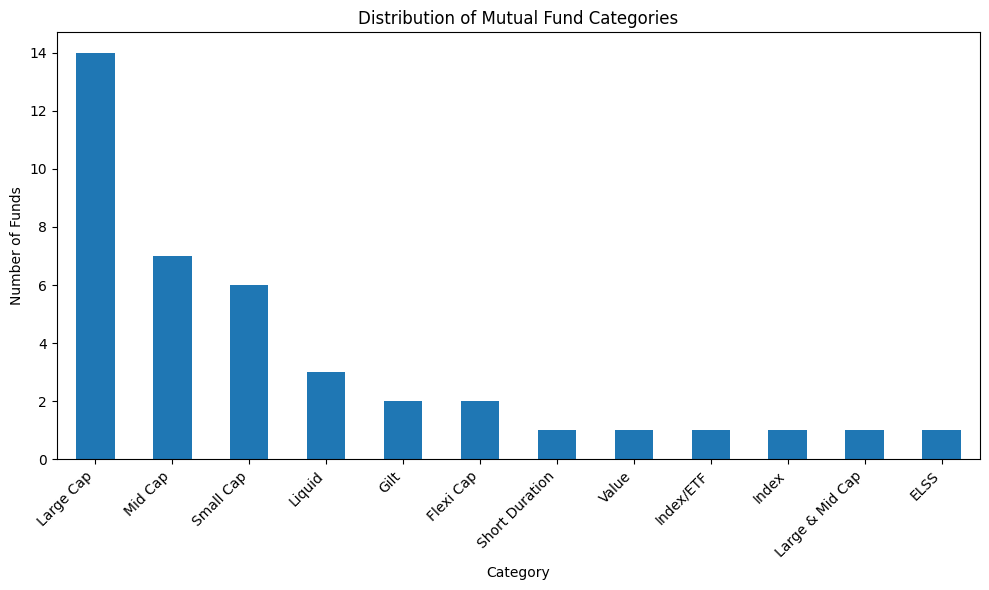

In [7]:
plt.figure(figsize=(10,6))

category_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution of Mutual Fund Categories"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Number of Funds"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

### Key Observations

1. Large Cap funds are the most common category with 14 schemes.
2. Mid Cap and Small Cap funds together contribute 13 schemes.
3. Equity-oriented categories dominate the dataset.
4. Specialized categories such as ELSS, Index, Value and ETF funds have relatively fewer offerings.

In [8]:
fund_master["expense_ratio_pct"].describe()

count    40.000000
mean      1.237000
std       0.386584
min       0.550000
25%       0.787500
50%       1.425000
75%       1.540000
max       1.640000
Name: expense_ratio_pct, dtype: float64

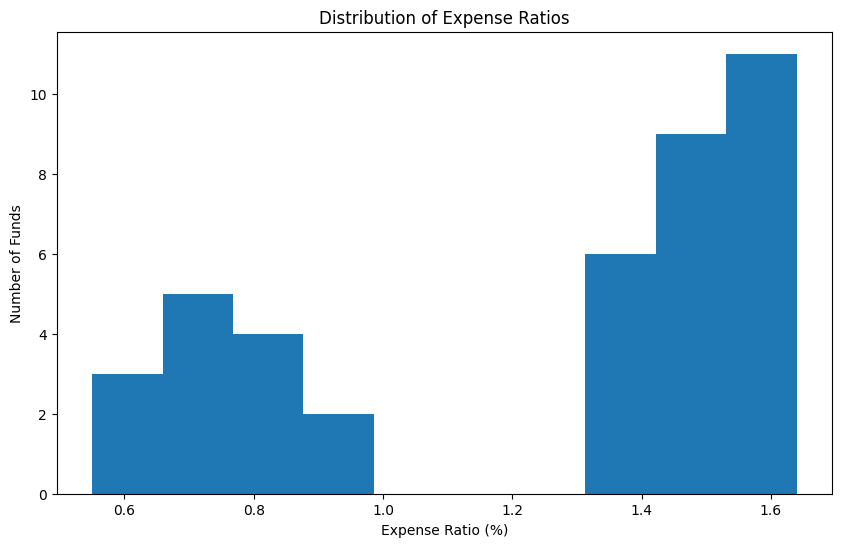

In [9]:
plt.figure(figsize=(10,6))

plt.hist(
    fund_master["expense_ratio_pct"],
    bins=10
)

plt.title(
    "Distribution of Expense Ratios"
)

plt.xlabel(
    "Expense Ratio (%)"
)

plt.ylabel(
    "Number of Funds"
)

plt.show()

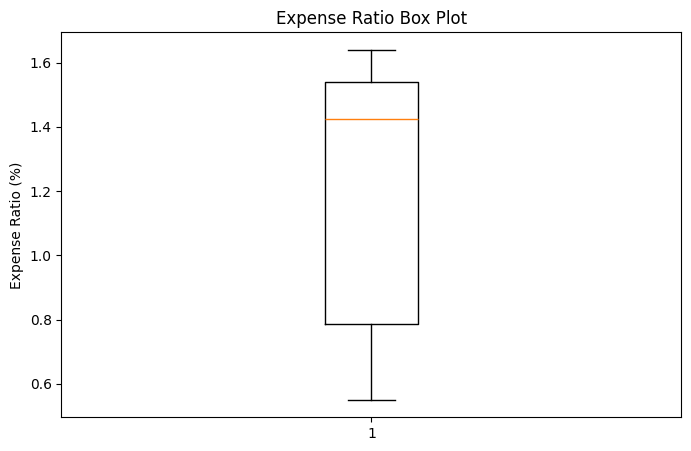

In [10]:
plt.figure(figsize=(8,5))

plt.boxplot(
    fund_master["expense_ratio_pct"]
)

plt.title(
    "Expense Ratio Box Plot"
)

plt.ylabel(
    "Expense Ratio (%)"
)

plt.show()

### Expense Ratio Analysis

1. The average expense ratio across all funds is 1.24%.
2. Expense ratios range from 0.55% to 1.64%.
3. The distribution appears bimodal, indicating two distinct groups of funds.
4. This pattern likely reflects Direct Plans (lower expenses) and Regular Plans (higher expenses).
5. No significant outliers were observed in the expense ratio distribution.

In [11]:
risk_counts = (
    fund_master["risk_category"]
    .value_counts()
)

risk_counts

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

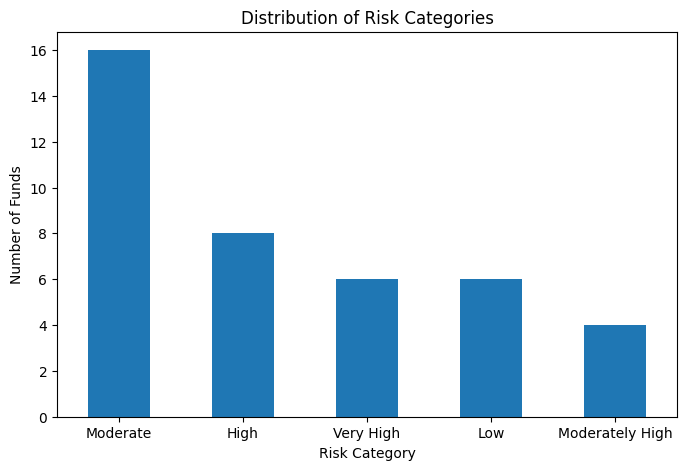

In [12]:
plt.figure(figsize=(8,5))

risk_counts.plot(
    kind="bar"
)

plt.title(
    "Distribution of Risk Categories"
)

plt.xlabel(
    "Risk Category"
)

plt.ylabel(
    "Number of Funds"
)

plt.xticks(rotation=0)

plt.show()

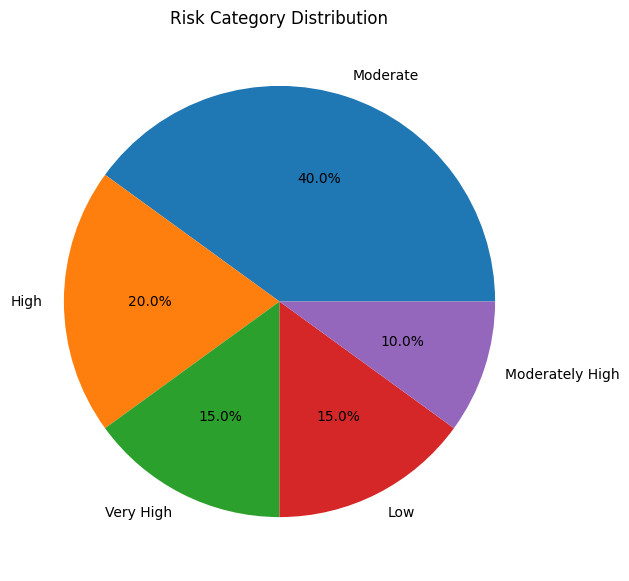

In [13]:
plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Risk Category Distribution"
)

plt.show()

### Risk Category Analysis

1. Moderate-risk funds account for 40% of all schemes.
2. High and Very High risk funds together account for 35% of schemes.
3. Low-risk funds represent only 15% of the dataset.
4. The dataset is skewed toward moderate and growth-oriented investment products.
5. Investors seeking conservative options have fewer scheme choices compared to moderate-risk investors.

In [14]:
top_1yr = (
    scheme_performance[
        ["scheme_name", "return_1yr_pct"]
    ]
    .sort_values(
        "return_1yr_pct",
        ascending=False
    )
    .head(10)
)

top_1yr

,scheme_name,return_1yr_pct
29,ABSL Small Cap Fund - Regular - Growth,24.93
2,SBI Small Cap Fund - Regular Plan - Growth,24.56
27,Axis Small Cap Fund - Regular - Growth,21.97
17,Nippon India Small Cap Fund - Regular - Growth,21.30
3,SBI Small Cap Fund - Direct Plan - Growth,20.59
39,DSP Small Cap Fund - Regular - Growth,20.20
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,19.98
33,UTI Flexi Cap Fund - Regular - Growth,17.43
21,Kotak Emerging Equity Fund - Regular - Growth,17.12
13,ICICI Pru Value Discovery Fund - Regular - Growth,16.67


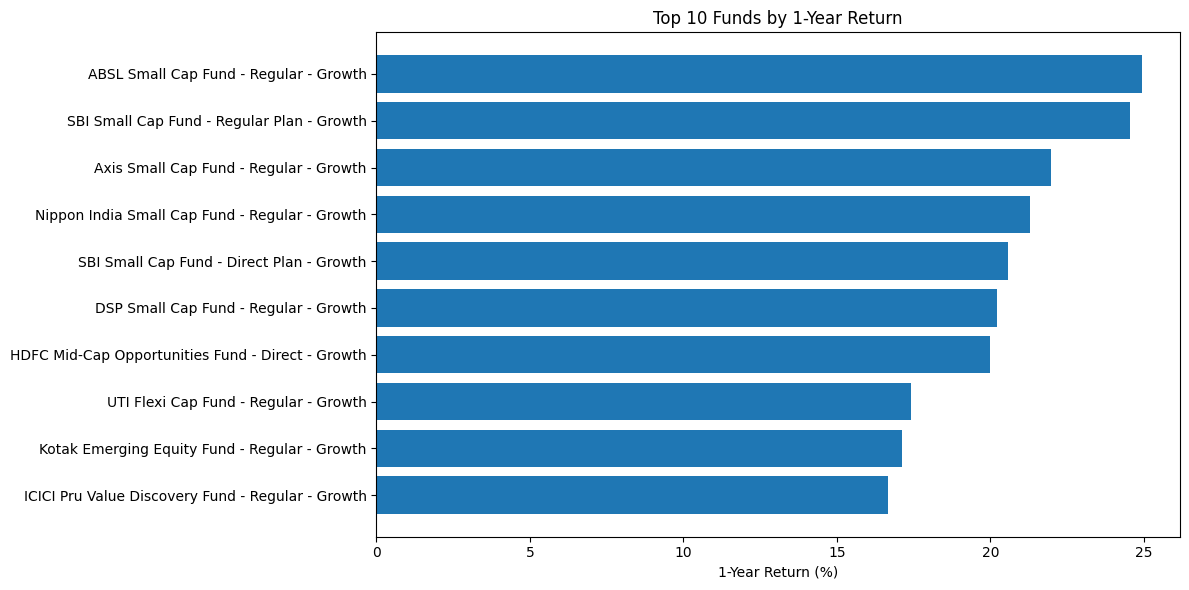

In [15]:
plt.figure(figsize=(12,6))

plt.barh(
    top_1yr["scheme_name"],
    top_1yr["return_1yr_pct"]
)

plt.title(
    "Top 10 Funds by 1-Year Return"
)

plt.xlabel(
    "1-Year Return (%)"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Top Performing Funds (1-Year Return)

1. Small-cap funds dominate the top 10 performers.
2. ABSL Small Cap Fund delivered the highest 1-year return (24.93%).
3. Six of the top ten schemes belong to the small-cap category.
4. Mid-cap and flexi-cap funds also appear among the leading performers.
5. Higher-return funds are generally associated with higher risk categories.

In [16]:
top_sharpe = (
    scheme_performance[
        ["scheme_name", "sharpe_ratio"]
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

top_sharpe

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


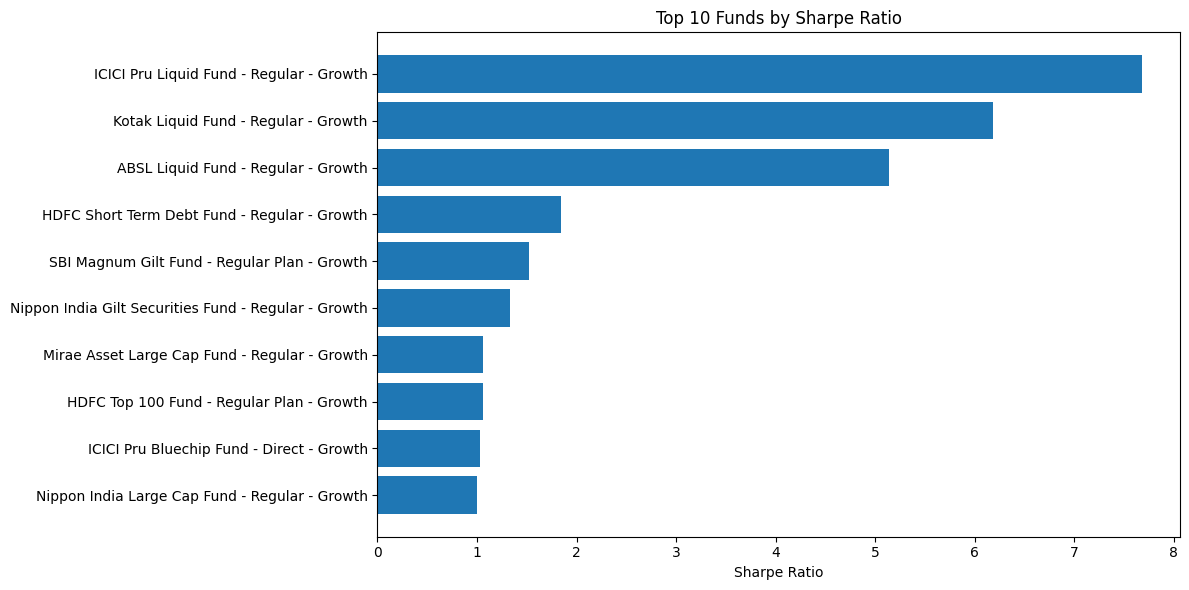

In [17]:
plt.figure(figsize=(12,6))

plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"]
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.xlabel(
    "Sharpe Ratio"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Sharpe Ratio Analysis

1. Liquid funds dominate the Sharpe Ratio rankings.
2. ICICI Pru Liquid Fund achieved the highest Sharpe Ratio (7.68).
3. Funds with the highest returns are not necessarily the best risk-adjusted performers.
4. Debt and liquid schemes provide superior risk-adjusted returns due to lower volatility.
5. Investors seeking stability may prefer high-Sharpe funds over high-return funds.

In [18]:
top_aum = (
    scheme_performance[
        ["scheme_name", "aum_crore"]
    ]
    .sort_values(
        "aum_crore",
        ascending=False
    )
    .head(10)
)

top_aum

,scheme_name,aum_crore
35,Mirae Asset Emerging Bluechip Fund - Regular -...,49046
21,Kotak Emerging Equity Fund - Regular - Growth,47469
17,Nippon India Small Cap Fund - Regular - Growth,43630
37,DSP Top 100 Equity Fund - Regular - Growth,41828
32,UTI Mid Cap Fund - Regular - Growth,41728
29,ABSL Small Cap Fund - Regular - Growth,41613
11,ICICI Pru Bluechip Fund - Direct - Growth,41553
16,Nippon India Large Cap Fund - Direct - Growth,39475
14,ICICI Pru Liquid Fund - Regular - Growth,39116
30,ABSL Liquid Fund - Regular - Growth,38995


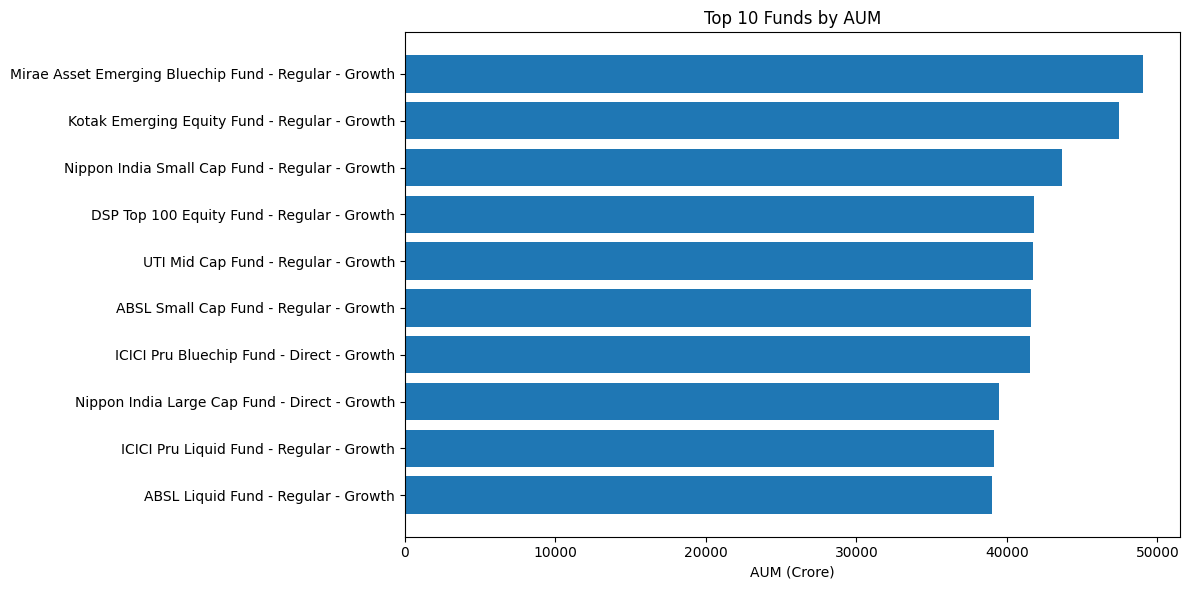

In [19]:
plt.figure(figsize=(12,6))

plt.barh(
    top_aum["scheme_name"],
    top_aum["aum_crore"]
)

plt.title(
    "Top 10 Funds by AUM"
)

plt.xlabel(
    "AUM (Crore)"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### AUM Analysis

1. Mirae Asset Emerging Bluechip Fund manages the highest AUM (₹49,046 crore).
2. Equity-oriented funds dominate the top AUM rankings.
3. Small-cap and mid-cap categories attract substantial investor capital.
4. Liquid funds continue to manage large asset bases despite lower return potential.
5. AUM concentration suggests strong investor preference for established schemes.

In [20]:
sector_counts = (
    portfolio_holdings["sector"]
    .value_counts()
)

sector_counts

sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Cement            12
NBFC              11
Paints            10
Consumer Goods     9
Name: count, dtype: int64

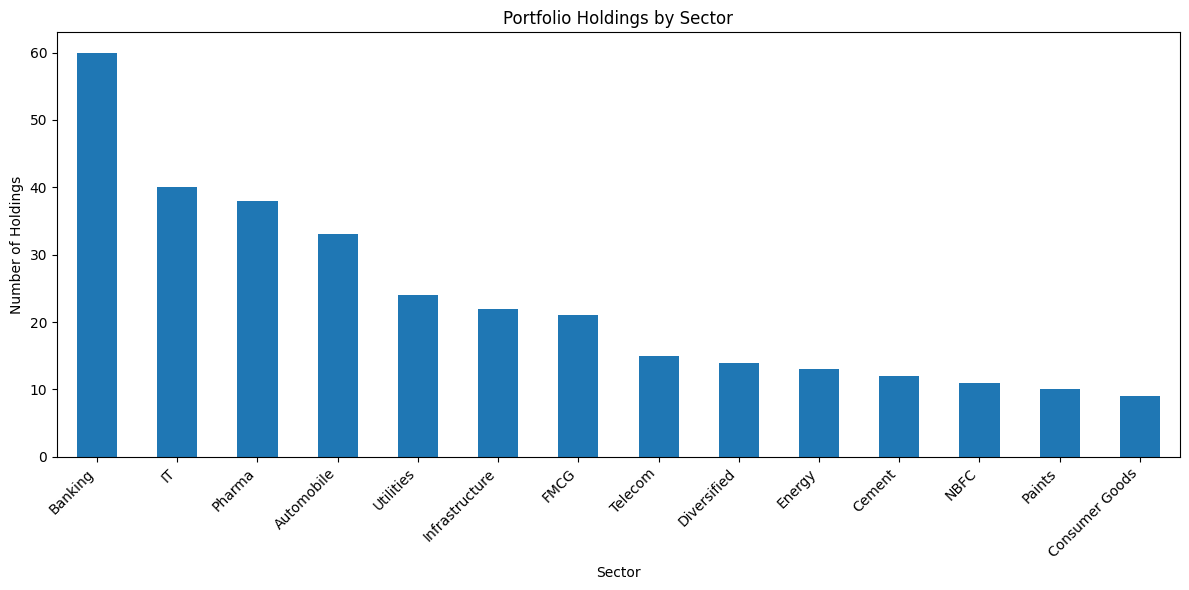

In [21]:
plt.figure(figsize=(12,6))

sector_counts.plot(
    kind="bar"
)

plt.title(
    "Portfolio Holdings by Sector"
)

plt.xlabel(
    "Sector"
)

plt.ylabel(
    "Number of Holdings"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

### Sector Analysis

1. Banking is the most represented sector with 60 holdings.
2. IT and Pharma are the second and third largest sectors.
3. The top five sectors account for more than 60% of all portfolio holdings.
4. Portfolio allocations indicate a preference for financial services, technology, healthcare, and consumer-driven industries.
5. Sector concentration is present but portfolios remain diversified across multiple industries.

In [22]:
top_stocks = (
    portfolio_holdings["stock_name"]
    .value_counts()
    .head(10)
)

top_stocks

stock_name
Bharti Airtel Ltd          15
Grasim Industries Ltd      14
NTPC Ltd                   13
HCL Technologies Ltd       13
ICICI Bank Ltd             13
Reliance Industries Ltd    13
Tata Motors Ltd            12
UltraTech Cement Ltd       12
Axis Bank Ltd              12
Adani Ports & SEZ Ltd      12
Name: count, dtype: int64

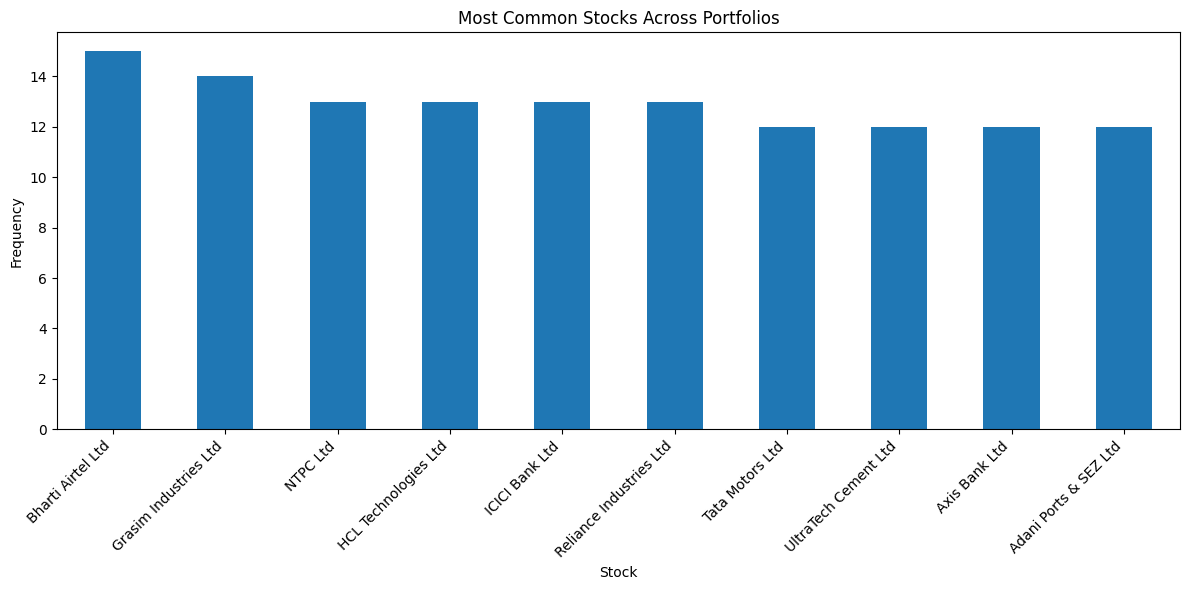

In [23]:
plt.figure(figsize=(12,6))

top_stocks.plot(kind="bar")

plt.title("Most Common Stocks Across Portfolios")

plt.xlabel("Stock")

plt.ylabel("Frequency")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Common Portfolio Holdings

1. Bharti Airtel is the most frequently held stock across portfolios.
2. Banking stocks such as ICICI Bank and Axis Bank appear among the most common holdings.
3. Reliance Industries remains a core portfolio component across multiple schemes.
4. Portfolio allocations favor large-cap market leaders across industries.
5. The most common holdings span banking, telecom, IT, energy, infrastructure, and automobile sectors.

# Key Findings and Conclusions

## Fund House Analysis
- SBI, HDFC, ICICI Prudential and Nippon India offer the largest number of schemes.

## Category Analysis
- Large Cap funds dominate the dataset.
- Equity-oriented categories account for over two-thirds of all schemes.

## Expense Ratio Analysis
- Average expense ratio is approximately 1.24%.
- Expense ratios exhibit a bimodal distribution due to Direct and Regular plans.

## Risk Analysis
- Moderate-risk funds form the largest category.
- Nearly 45% of schemes belong to higher-risk categories.

## Performance Analysis
- Small-cap funds dominate the top-return rankings.
- ABSL Small Cap Fund achieved the highest 1-year return.

## Sharpe Ratio Analysis
- Liquid funds deliver the strongest risk-adjusted returns.
- High-return funds are not necessarily high-Sharpe funds.

## AUM Analysis
- Mirae Asset Emerging Bluechip Fund manages the highest AUM.
- Equity funds attract the largest share of investor capital.

## Portfolio Analysis
- Banking is the most represented sector.
- Bharti Airtel, Reliance Industries and major banking stocks are common holdings across portfolios.